In [37]:
import torch
import tensordict
from tensordict import TensorDict
from transformers import AutoTokenizer
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

In [38]:
tokenizer = AutoTokenizer.from_pretrained("qwen/Qwen2.5-32B")

In [39]:
root_dir = "/mnt/blob/ckpts/DAPO-PPO/Qwen2.5-32B-GS-PR-nc/artifacts/"

# Load multiple steps and merge the data
steps = [341, 342, 343, 344]
all_data = []

for step in steps:
    step_dir = f"{root_dir}{step}"
    td = TensorDict.load(step_dir)
    
    # Store step information
    td_with_step = {"step": step, "tensordict": td}
    all_data.append(td_with_step)
    
    print(f"Loaded step {step}")

Loaded step 341
Loaded step 342
Loaded step 342
Loaded step 343
Loaded step 344
Loaded step 343
Loaded step 344


In [40]:
# Create empty lists to store the extracted data
all_seqs_list = []
all_responses_list = []
all_prompts_list = []
all_values_list = []
all_response_lengths = []
all_step_info = []

# Process each step's data
for step_data in all_data:
    step = step_data["step"]
    td = step_data["tensordict"]
    
    seqs_list = []
    responses_list = []
    prompts_list = []
    values_list = []
    
    offset = 0
    for i in range(0, len(td["full_lengths"])):
        full_length = td["full_lengths"][i]
        seq = td["seqs"][offset:offset + full_length]
        seqs_list.append(seq)
        
        response_length = td["response_lengths"][i]
        all_response_lengths.append(response_length.item())
        
        cache_length = td["cache_lengths"][i].to(torch.int64)
        prompt_length = full_length - response_length - cache_length
        prompt = td["seqs"][offset:offset + prompt_length.item()]
        prompts_list.append(prompt)
        
        response = td["seqs"][offset+prompt_length.item():offset + full_length.item()]
        responses_list.append(response)
        
        offset += full_length
        
        values = td["values"][i]
        values = values[values != 0.]
        values_list.append(values)
        
        # Add step information
        all_step_info.append(step)
    
    # Extend the master lists
    all_seqs_list.extend(seqs_list)
    all_responses_list.extend(responses_list)
    all_prompts_list.extend(prompts_list)
    all_values_list.extend(values_list)
    
    print(f"Processed {len(seqs_list)} sequences from step {step}")

print(f"Total sequences processed: {len(all_seqs_list)}")

Processed 512 sequences from step 341


Processed 512 sequences from step 342
Processed 512 sequences from step 343
Processed 512 sequences from step 343
Processed 512 sequences from step 344
Total sequences processed: 2048
Processed 512 sequences from step 344
Total sequences processed: 2048


In [41]:
# Extract the first token value for each sequence
first_token_values = []
for value_tensor in all_values_list:
    if len(value_tensor) > 0:
        first_token_values.append(float(value_tensor[0]))
    else:
        first_token_values.append(np.nan)

# Create a DataFrame for analysis
correlation_df = pd.DataFrame({
    'step': all_step_info,
    'first_token_value': first_token_values,
    'response_length': all_response_lengths
})

# Remove any NaN values
correlation_df = correlation_df.dropna()

# Print basic statistics
print("Descriptive statistics for first token values:")
print(correlation_df['first_token_value'].describe())
print("\nDescriptive statistics for response lengths:")
print(correlation_df['response_length'].describe())

Descriptive statistics for first token values:
count    2048.000000
mean        0.021432
std         0.552903
min        -1.156250
25%        -0.539062
50%         0.134766
75%         0.511719
max         0.968750
Name: first_token_value, dtype: float64

Descriptive statistics for response lengths:
count     2048.000000
mean      3052.896973
std       2982.935278
min        316.000000
25%       1144.250000
50%       1885.500000
75%       3660.500000
max      12288.000000
Name: response_length, dtype: float64


In [42]:
# Calculate the correlation coefficient
correlation = correlation_df['first_token_value'].corr(correlation_df['response_length'])
print(f"Pearson correlation coefficient (overall): {correlation:.4f}")

# Calculate correlation by step
step_correlations = correlation_df.groupby('step').apply(
    lambda x: x['first_token_value'].corr(x['response_length'])
)
print("\nCorrelation by step:")
for step, corr in step_correlations.items():
    print(f"Step {step}: {corr:.4f}")

Pearson correlation coefficient (overall): -0.2871

Correlation by step:
Step 341: -0.3856
Step 342: -0.3469
Step 343: -0.2152
Step 344: -0.1989


/tmp/ipykernel_85954/907337669.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  step_correlations = correlation_df.groupby('step').apply(


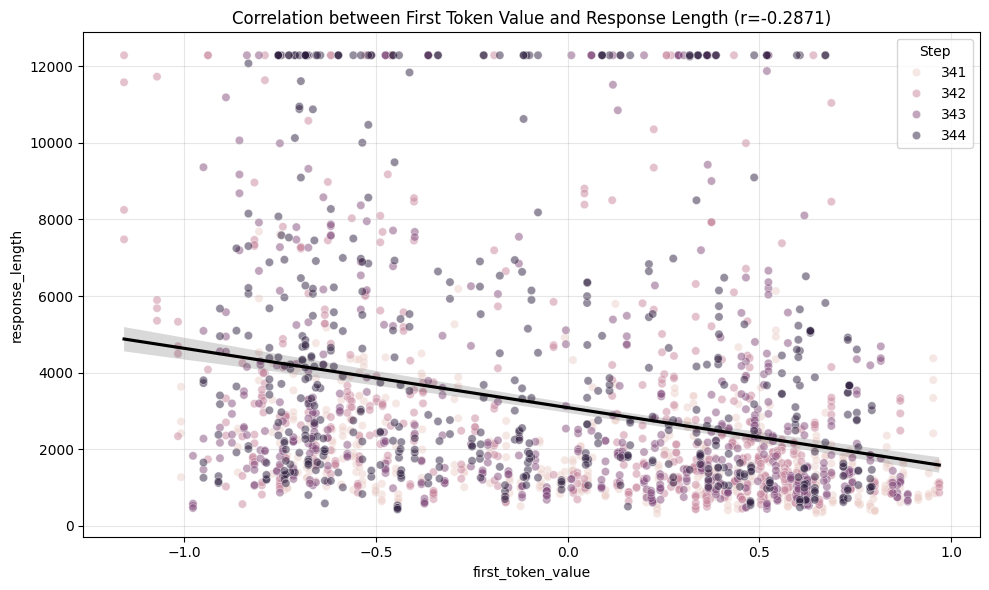

In [43]:
# Plot the overall relationship
plt.figure(figsize=(10, 6))
sns.scatterplot(x='first_token_value', y='response_length', 
                hue='step', data=correlation_df, alpha=0.5)
plt.title(f'Correlation between First Token Value and Response Length (r={correlation:.4f})')
plt.xlabel('First Token Value')
plt.ylabel('Response Length')
plt.grid(True, alpha=0.3)

# Add a regression line
sns.regplot(x='first_token_value', y='response_length', 
            data=correlation_df, scatter=False, line_kws={'color': 'black'})

plt.legend(title='Step')
plt.tight_layout()
plt.show()

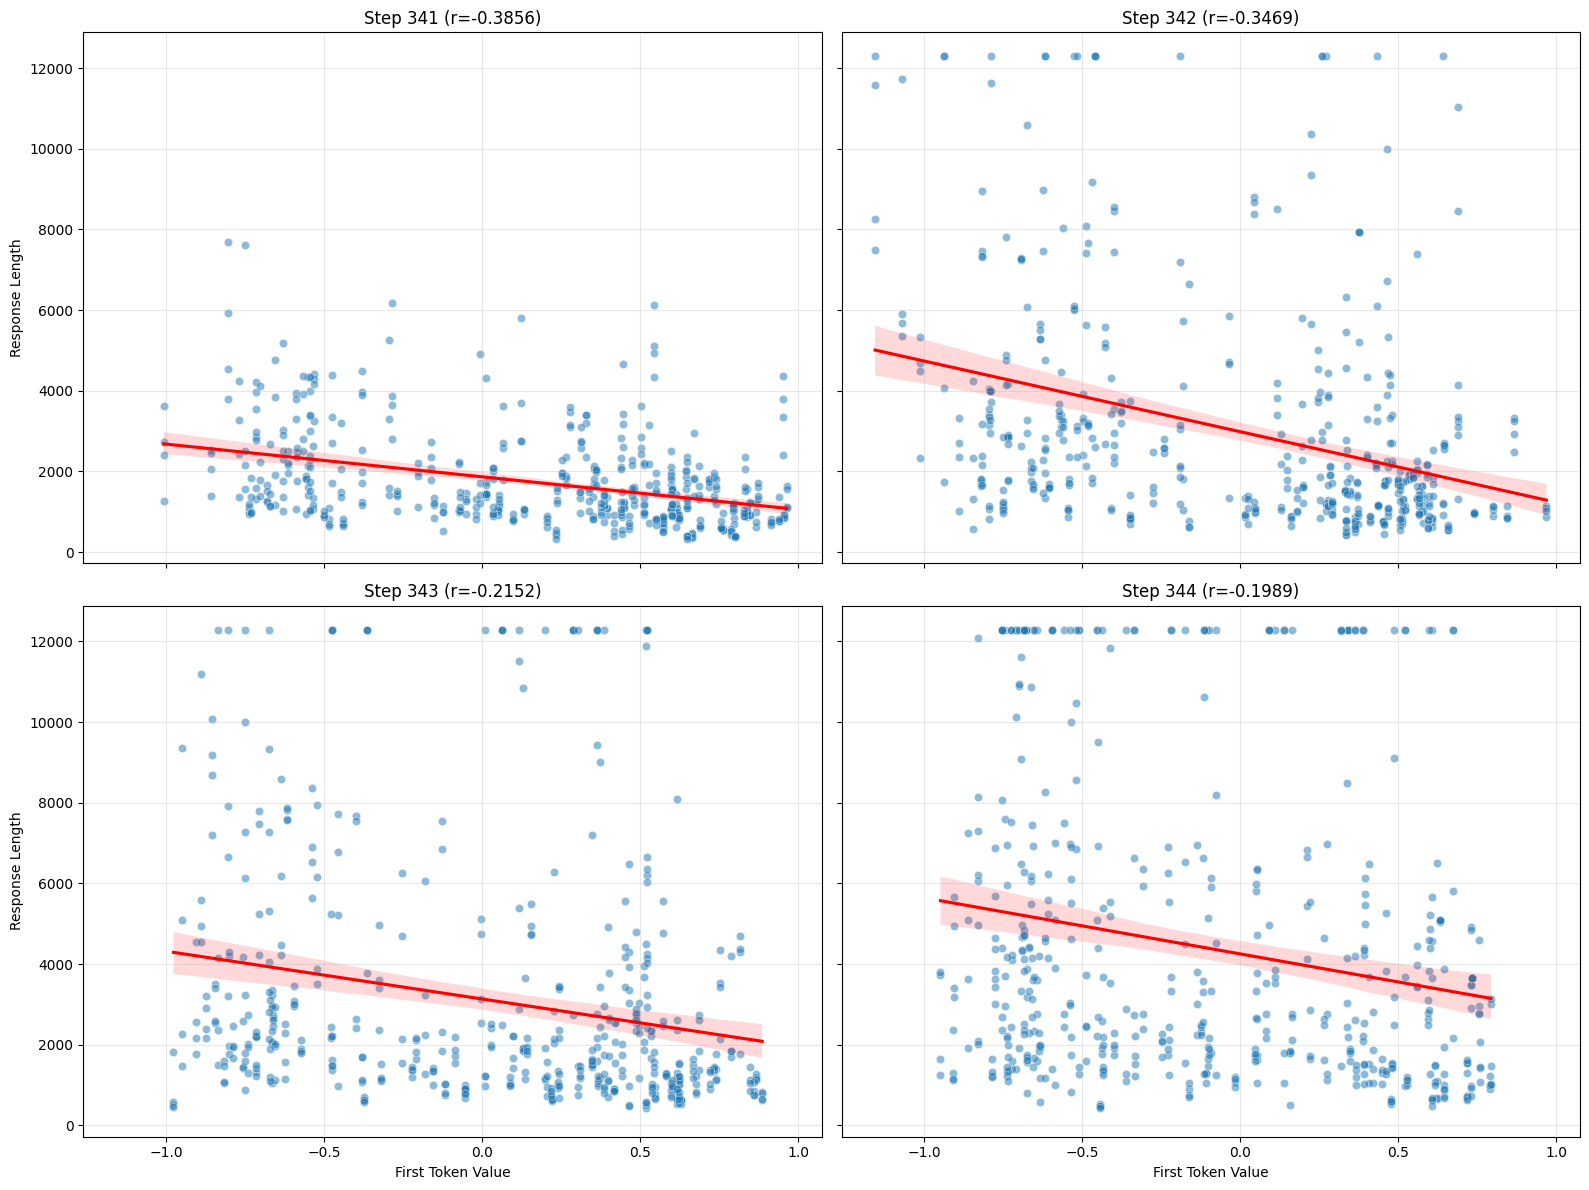

In [44]:
# Create a figure with multiple subplots for each step
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
axes = axes.flatten()

for i, step in enumerate(steps):
    step_data = correlation_df[correlation_df['step'] == step]
    step_corr = step_data['first_token_value'].corr(step_data['response_length'])
    
    sns.scatterplot(x='first_token_value', y='response_length', 
                   data=step_data, alpha=0.5, ax=axes[i])
    
    sns.regplot(x='first_token_value', y='response_length', 
               data=step_data, scatter=False, 
               line_kws={'color': 'red'}, ax=axes[i])
    
    axes[i].set_title(f'Step {step} (r={step_corr:.4f})')
    axes[i].set_xlabel('First Token Value')
    axes[i].set_ylabel('Response Length')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Analysis by bins of first token value (all steps):
                       value_bin         mean  count          std bin_center
0  (-1.1569999999999998, -0.738]  4147.947115    208  3202.947419    -0.9475
1               (-0.738, -0.617]  4270.449074    216  3374.068861    -0.6775
2               (-0.617, -0.447]  4189.583333    192  3322.612046    -0.5320
3               (-0.447, -0.127]  3203.661765    204  2909.666906    -0.2870
4                (-0.127, 0.135]  3071.000000    204  3195.246277     0.0040
5                 (0.135, 0.336]  2915.480769    208  3006.789774     0.2355
6                 (0.336, 0.453]  2650.279412    204  2904.443492     0.3945
7                 (0.453, 0.566]  2556.427885    208  2507.520899     0.5095
8                 (0.566, 0.672]  1850.585000    200  2116.991316     0.6190
9                 (0.672, 0.969]  1636.181373    204  1325.179568     0.8205


/tmp/ipykernel_85954/2853157467.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_analysis = correlation_df.groupby(['value_bin'])['response_length'].agg(['mean', 'count', 'std']).reset_index()


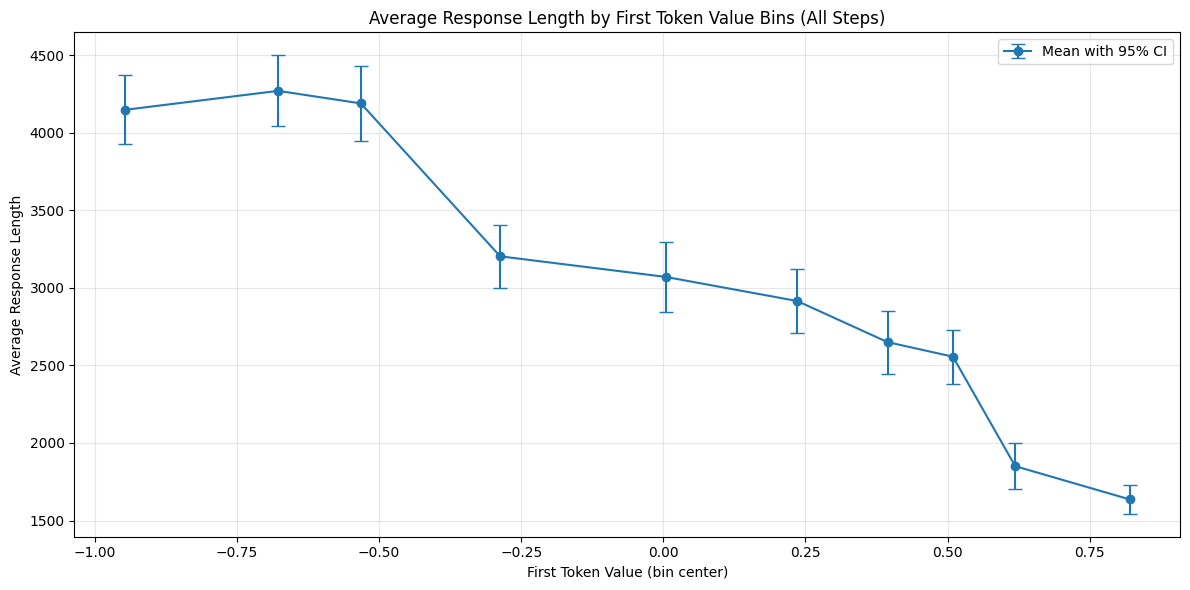

In [45]:
# Group data into bins based on first token values for a clearer view
# Create 10 bins across all data
correlation_df['value_bin'] = pd.qcut(correlation_df['first_token_value'], 10, duplicates='drop')

# Calculate average response length for each bin
bin_analysis = correlation_df.groupby(['value_bin'])['response_length'].agg(['mean', 'count', 'std']).reset_index()
bin_analysis['bin_center'] = bin_analysis['value_bin'].apply(lambda x: x.mid)

# Sort by bin center
bin_analysis = bin_analysis.sort_values('bin_center')

# Display the binned analysis
print("\nAnalysis by bins of first token value (all steps):")
print(bin_analysis)

# Plot the binned relationship
plt.figure(figsize=(12, 6))

# Plot with error bars
plt.errorbar(bin_analysis['bin_center'], bin_analysis['mean'], 
             yerr=bin_analysis['std']/np.sqrt(bin_analysis['count']), 
             fmt='o-', capsize=5, label='Mean with 95% CI')

plt.title('Average Response Length by First Token Value Bins (All Steps)')
plt.xlabel('First Token Value (bin center)')
plt.ylabel('Average Response Length')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

## Distribution Analysis

Let's also look at the distributions of both variables to better understand their patterns.

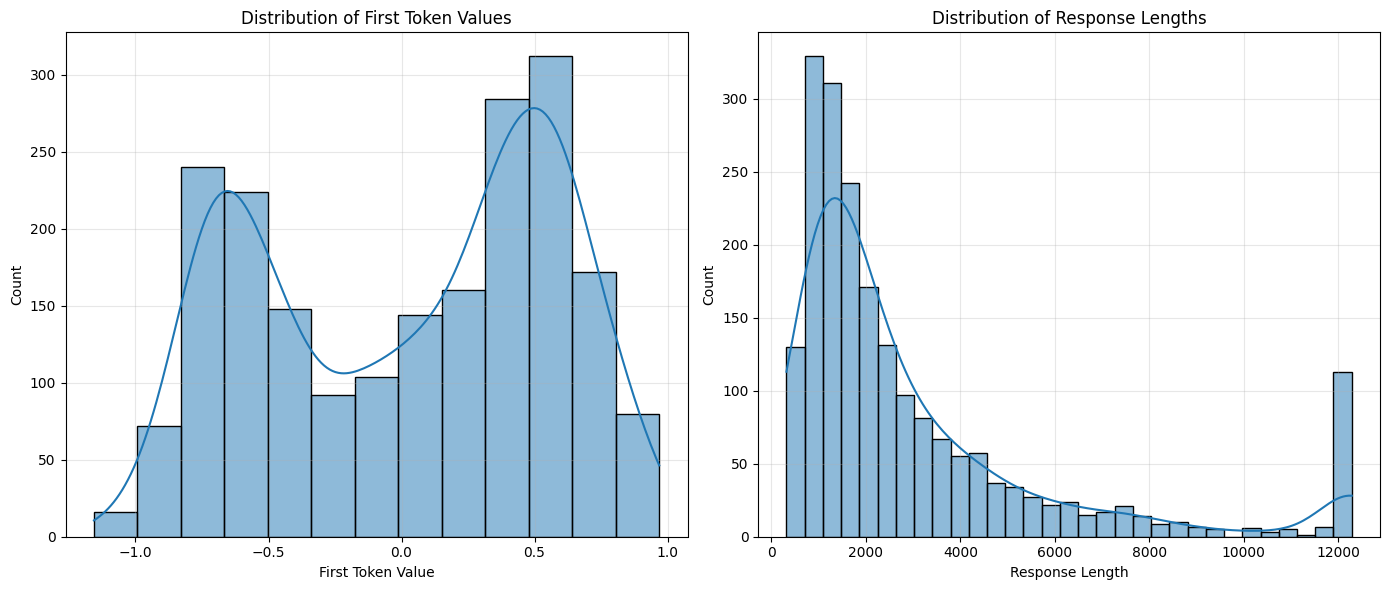

In [46]:
# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot histogram of first token values
sns.histplot(correlation_df['first_token_value'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of First Token Values')
axes[0].set_xlabel('First Token Value')
axes[0].grid(True, alpha=0.3)

# Plot histogram of response lengths
sns.histplot(correlation_df['response_length'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Response Lengths')
axes[1].set_xlabel('Response Length')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
# Checking for outliers and their impact on correlation
# Define a function to compute correlation with different percentiles of data
def compute_correlation_without_extremes(df, column1, column2, lower_percentile, upper_percentile):
    lower_bound = df[column1].quantile(lower_percentile)
    upper_bound = df[column1].quantile(upper_percentile)
    filtered_df = df[(df[column1] >= lower_bound) & (df[column1] <= upper_bound)]
    return filtered_df[column1].corr(filtered_df[column2])

# Calculate correlation excluding outliers at different levels
percentiles = [(0, 1), (0.01, 0.99), (0.05, 0.95), (0.1, 0.9)]
results = []

for lower, upper in percentiles:
    # Overall correlation
    overall_corr = compute_correlation_without_extremes(
        correlation_df, 'first_token_value', 'response_length', lower, upper)
    
    # Step-wise correlations
    step_correlations = {}
    for step in steps:
        step_data = correlation_df[correlation_df['step'] == step]
        step_corr = compute_correlation_without_extremes(
            step_data, 'first_token_value', 'response_length', lower, upper)
        step_correlations[f'step_{step}'] = step_corr
    
    result = {
        'percentile_range': f'{lower*100}%-{upper*100}%',
        'data_included': f'{upper-lower:.2%}',
        'overall_correlation': overall_corr
    }
    result.update(step_correlations)
    results.append(result)

# Display results
correlation_robustness = pd.DataFrame(results)
print("\nCorrelation robustness to outliers:")
print(correlation_robustness)


Correlation robustness to outliers:
  percentile_range data_included  overall_correlation  step_341  step_342  \
0          0%-100%       100.00%            -0.287125 -0.385573 -0.346950   
1       1.0%-99.0%        98.00%            -0.277786 -0.382274 -0.313909   
2       5.0%-95.0%        90.00%            -0.253375 -0.369541 -0.281089   
3      10.0%-90.0%        80.00%            -0.230017 -0.341200 -0.292582   

   step_343  step_344  
0 -0.215194 -0.198894  
1 -0.222431 -0.201588  
2 -0.180201 -0.192389  
3 -0.159777 -0.158869  


# Analyzing Correlation with Multiple Tokens

Since the first token showed moderate but decreasing correlation across steps, let's examine if using multiple tokens (average of first 10 tokens) provides a more consistent predictor for response length.

In [48]:
# Extract the first 10 token values (or as many as available) for each sequence
first_token_values = []  # Keep this for comparison
first_10_avg_values = []
first_5_avg_values = []
first_3_avg_values = []

for value_tensor in all_values_list:
    if len(value_tensor) > 0:
        # First token value
        first_token_values.append(float(value_tensor[0]))
        
        # First 3 tokens average
        first_3 = value_tensor[:min(3, len(value_tensor))]
        first_3_avg_values.append(float(first_3.mean()))
        
        # First 5 tokens average
        first_5 = value_tensor[:min(5, len(value_tensor))]
        first_5_avg_values.append(float(first_5.mean()))
        
        # First 10 tokens average
        first_10 = value_tensor[:min(10, len(value_tensor))]
        first_10_avg_values.append(float(first_10.mean()))
    else:
        first_token_values.append(np.nan)
        first_3_avg_values.append(np.nan)
        first_5_avg_values.append(np.nan)
        first_10_avg_values.append(np.nan)

# Create a DataFrame for analysis with multiple token metrics
multi_token_df = pd.DataFrame({
    'step': all_step_info,
    'first_token_value': first_token_values,
    'first_3_avg': first_3_avg_values,
    'first_5_avg': first_5_avg_values,
    'first_10_avg': first_10_avg_values,
    'response_length': all_response_lengths
})

# Remove any NaN values
multi_token_df = multi_token_df.dropna()

# Print basic statistics for multi-token metrics
print("Descriptive statistics for first token values:")
print(multi_token_df['first_token_value'].describe())
print("\nDescriptive statistics for average of first 3 tokens:")
print(multi_token_df['first_3_avg'].describe())
print("\nDescriptive statistics for average of first 5 tokens:")
print(multi_token_df['first_5_avg'].describe())
print("\nDescriptive statistics for average of first 10 tokens:")
print(multi_token_df['first_10_avg'].describe())
print("\nDescriptive statistics for response lengths:")
print(multi_token_df['response_length'].describe())

Descriptive statistics for first token values:
count    2048.000000
mean        0.021432
std         0.552903
min        -1.156250
25%        -0.539062
50%         0.134766
75%         0.511719
max         0.968750
Name: first_token_value, dtype: float64

Descriptive statistics for average of first 3 tokens:
count    2048.000000
mean       -0.018327
std         0.570997
min        -1.187500
25%        -0.609375
50%         0.128906
75%         0.494629
max         0.890625
Name: first_3_avg, dtype: float64

Descriptive statistics for average of first 5 tokens:
count    2048.000000
mean       -0.042425
std         0.569354
min        -1.195312
25%        -0.640625
50%         0.106445
75%         0.466309
max         0.867188
Name: first_5_avg, dtype: float64

Descriptive statistics for average of first 10 tokens:
count    2048.000000
mean       -0.060387
std         0.589725
min        -1.273438
25%        -0.660156
50%         0.098145
75%         0.461426
max         0.902344
Name: f

In [49]:
# Calculate the correlation coefficients for different metrics
correlation_metrics = {
    'first_token': multi_token_df['first_token_value'].corr(multi_token_df['response_length']),
    'first_3_avg': multi_token_df['first_3_avg'].corr(multi_token_df['response_length']),
    'first_5_avg': multi_token_df['first_5_avg'].corr(multi_token_df['response_length']),
    'first_10_avg': multi_token_df['first_10_avg'].corr(multi_token_df['response_length'])
}

print("Overall correlation coefficients:")
for metric, corr in correlation_metrics.items():
    print(f"{metric}: {corr:.4f}")
    
# Calculate correlation by step for each metric
print("\nCorrelation by step:")
for step in steps:
    step_data = multi_token_df[multi_token_df['step'] == step]
    print(f"\nStep {step}:")
    for col in ['first_token_value', 'first_3_avg', 'first_5_avg', 'first_10_avg']:
        corr = step_data[col].corr(step_data['response_length'])
        print(f"{col}: {corr:.4f}")

Overall correlation coefficients:
first_token: -0.2871
first_3_avg: -0.3060
first_5_avg: -0.3104
first_10_avg: -0.3151

Correlation by step:

Step 341:
first_token_value: -0.3856
first_3_avg: -0.4052
first_5_avg: -0.4062
first_10_avg: -0.4109

Step 342:
first_token_value: -0.3469
first_3_avg: -0.3767
first_5_avg: -0.3809
first_10_avg: -0.3866

Step 343:
first_token_value: -0.2152
first_3_avg: -0.2438
first_5_avg: -0.2486
first_10_avg: -0.2508

Step 344:
first_token_value: -0.1989
first_3_avg: -0.2156
first_5_avg: -0.2194
first_10_avg: -0.2265


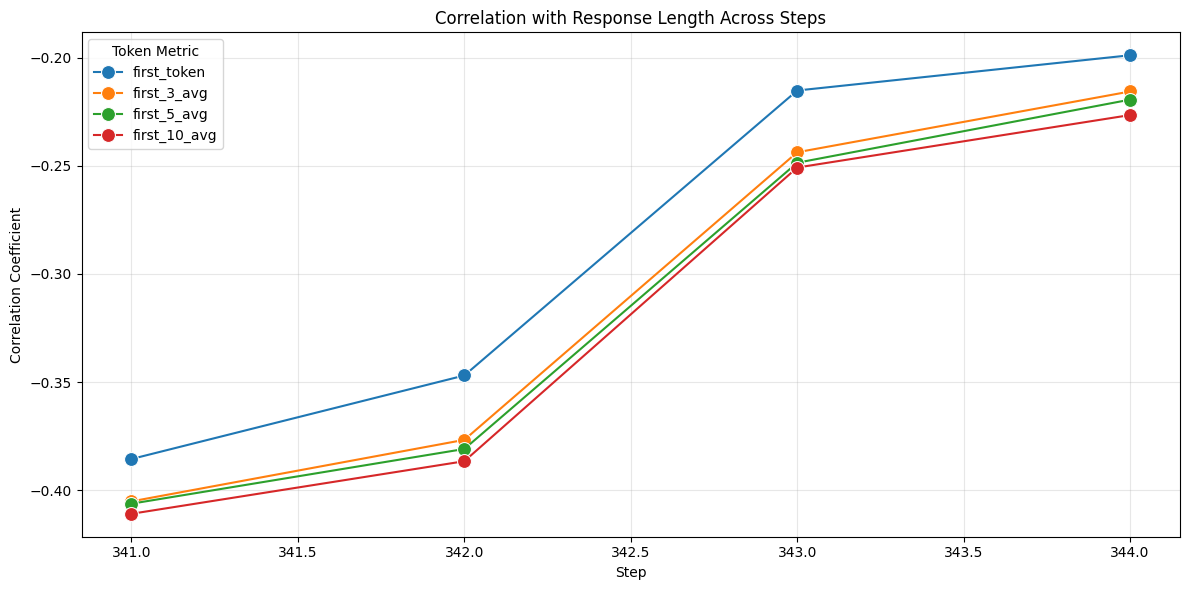

In [50]:
# Create a figure to compare the correlations across steps
step_correlations = []

for step in steps:
    step_data = multi_token_df[multi_token_df['step'] == step]
    step_corr = {
        'step': step,
        'first_token': step_data['first_token_value'].corr(step_data['response_length']),
        'first_3_avg': step_data['first_3_avg'].corr(step_data['response_length']),
        'first_5_avg': step_data['first_5_avg'].corr(step_data['response_length']),
        'first_10_avg': step_data['first_10_avg'].corr(step_data['response_length'])
    }
    step_correlations.append(step_corr)

step_corr_df = pd.DataFrame(step_correlations)

# Melt the dataframe for easier plotting
step_corr_melted = pd.melt(step_corr_df, id_vars=['step'], 
                           value_vars=['first_token', 'first_3_avg', 'first_5_avg', 'first_10_avg'],
                           var_name='metric', value_name='correlation')

# Plot the correlations across steps
plt.figure(figsize=(12, 6))
sns.lineplot(data=step_corr_melted, x='step', y='correlation', hue='metric', marker='o', markersize=10)
plt.title('Correlation with Response Length Across Steps')
plt.xlabel('Step')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)
plt.legend(title='Token Metric')
plt.tight_layout()
plt.show()

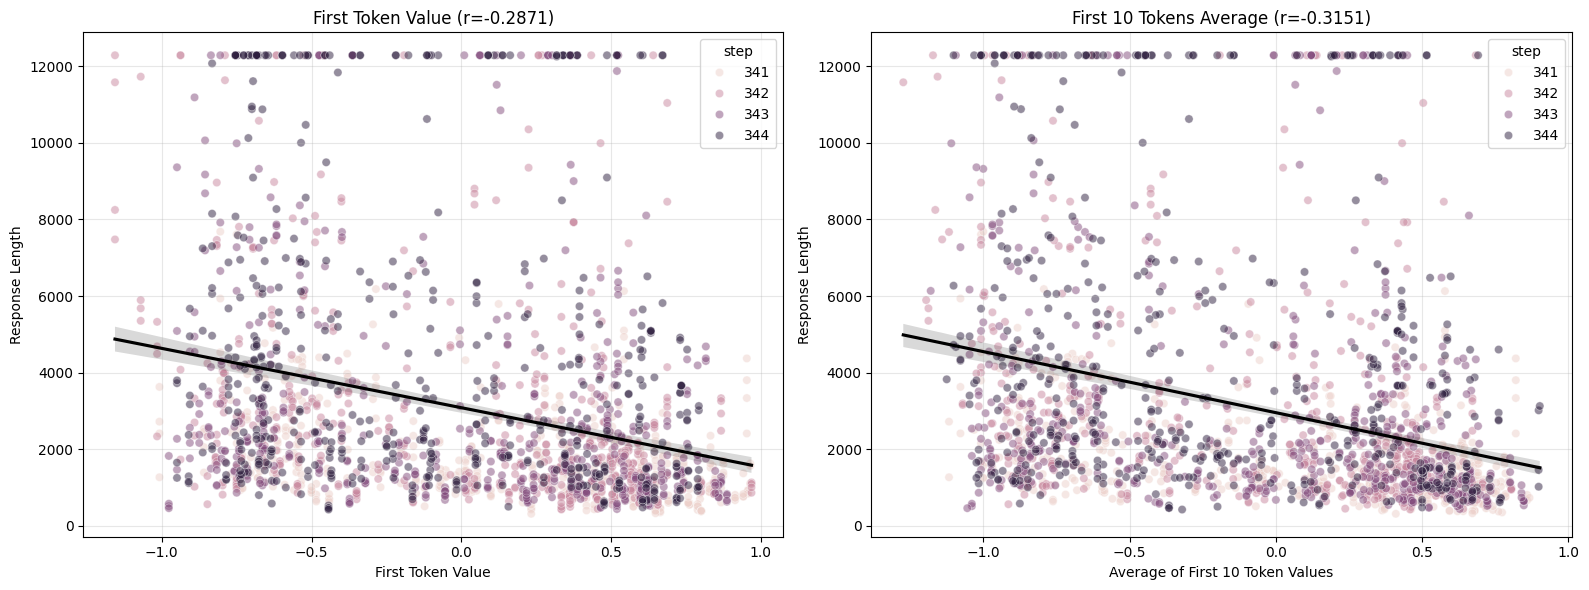

In [51]:
# Compare scatter plots for first token vs first 10 tokens average
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# First token value
sns.scatterplot(x='first_token_value', y='response_length', 
                hue='step', data=multi_token_df, alpha=0.5, ax=axes[0])
sns.regplot(x='first_token_value', y='response_length', 
            data=multi_token_df, scatter=False, 
            line_kws={'color': 'black'}, ax=axes[0])
axes[0].set_title(f'First Token Value (r={correlation_metrics["first_token"]:.4f})')
axes[0].set_xlabel('First Token Value')
axes[0].set_ylabel('Response Length')
axes[0].grid(True, alpha=0.3)

# First 10 tokens average
sns.scatterplot(x='first_10_avg', y='response_length', 
                hue='step', data=multi_token_df, alpha=0.5, ax=axes[1])
sns.regplot(x='first_10_avg', y='response_length', 
            data=multi_token_df, scatter=False, 
            line_kws={'color': 'black'}, ax=axes[1])
axes[1].set_title(f'First 10 Tokens Average (r={correlation_metrics["first_10_avg"]:.4f})')
axes[1].set_xlabel('Average of First 10 Token Values')
axes[1].set_ylabel('Response Length')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

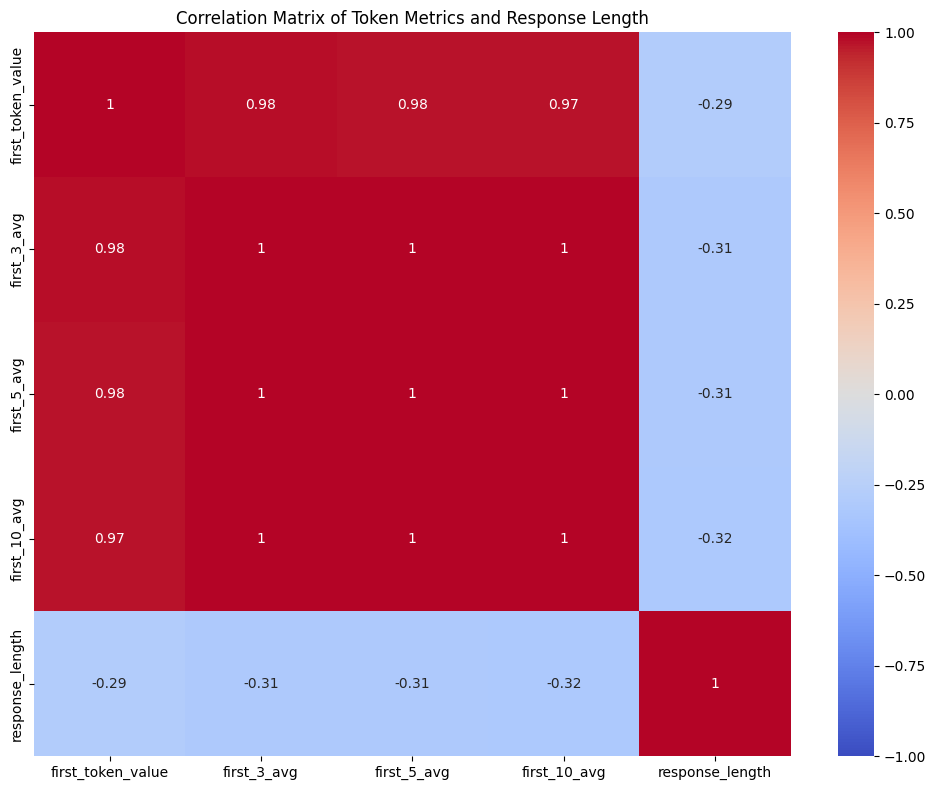

In [52]:
# Create heatmap to visualize correlation matrix
correlation_matrix = multi_token_df[['first_token_value', 'first_3_avg', 'first_5_avg', 
                                    'first_10_avg', 'response_length']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Matrix of Token Metrics and Response Length')
plt.tight_layout()
plt.show()

Analysis by bins of first 10 tokens average (all steps):
                    value_bin_10         mean  count          std bin_center
0  (-1.2739999999999998, -0.883]  4747.912442    217  3438.991229   -1.07850
1                (-0.883, -0.75]  3664.413265    196  3182.498937   -0.81650
2                (-0.75, -0.547]  3986.610837    203  2931.954015   -0.64850
3               (-0.547, -0.224]  3743.763547    203  3422.201857   -0.38550
4               (-0.224, 0.0981]  2967.671498    207  2895.799539   -0.06295
5                (0.0981, 0.305]  3160.264423    208  3464.323365    0.20155
6                 (0.305, 0.418]  2628.050251    199  2475.548173    0.36150
7                 (0.418, 0.512]  2247.400000    210  2367.298362    0.46500
8                 (0.512, 0.645]  1866.173267    202  1703.025106    0.57850
9                 (0.645, 0.902]  1433.492611    203  1474.742372    0.77350


/tmp/ipykernel_85954/3376707667.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bin_analysis_10 = multi_token_df.groupby(['value_bin_10'])['response_length'].agg(['mean', 'count', 'std']).reset_index()


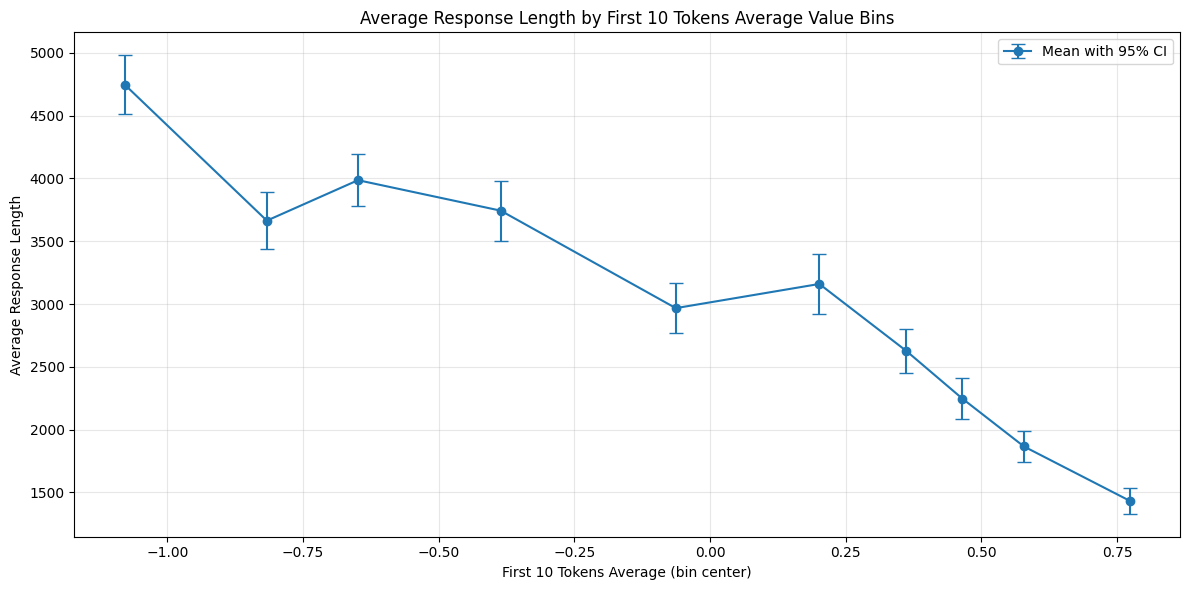

In [53]:
# Bin analysis for first 10 tokens average
multi_token_df['value_bin_10'] = pd.qcut(multi_token_df['first_10_avg'], 10, duplicates='drop')

# Calculate bin statistics
bin_analysis_10 = multi_token_df.groupby(['value_bin_10'])['response_length'].agg(['mean', 'count', 'std']).reset_index()
bin_analysis_10['bin_center'] = bin_analysis_10['value_bin_10'].apply(lambda x: x.mid)
bin_analysis_10 = bin_analysis_10.sort_values('bin_center')

print("Analysis by bins of first 10 tokens average (all steps):")
print(bin_analysis_10)

# Plot the binned relationship
plt.figure(figsize=(12, 6))
plt.errorbar(bin_analysis_10['bin_center'], bin_analysis_10['mean'], 
             yerr=bin_analysis_10['std']/np.sqrt(bin_analysis_10['count']), 
             fmt='o-', capsize=5, label='Mean with 95% CI')
plt.title('Average Response Length by First 10 Tokens Average Value Bins')
plt.xlabel('First 10 Tokens Average (bin center)')
plt.ylabel('Average Response Length')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

## Analysis of Token-by-Token Correlation

Let's also examine how the correlation changes for individual token positions across the response.

In [54]:
# Analyze correlation for individual token positions (1st, 2nd, 3rd, etc.)
max_tokens_to_analyze = 20  # Analyze up to the first 20 tokens
position_corr = []

for pos in range(max_tokens_to_analyze):
    token_values = []
    response_lengths = []
    steps = []
    
    for i, values in enumerate(all_values_list):
        if len(values) > pos:  # Check if this position exists
            token_values.append(float(values[pos]))
            response_lengths.append(all_response_lengths[i])
            steps.append(all_step_info[i])
    
    # Create a DataFrame for this position
    pos_df = pd.DataFrame({
        'token_value': token_values,
        'response_length': response_lengths,
        'step': steps
    })
    
    # Calculate overall correlation
    overall_corr = pos_df['token_value'].corr(pos_df['response_length'])
    
    # Calculate correlation by step
    step_corrs = {}
    for step in pd.unique(pos_df['step']):
        step_data = pos_df[pos_df['step'] == step]
        step_corrs[step] = step_data['token_value'].corr(step_data['response_length'])
    
    position_corr.append({
        'position': pos + 1,  # 1-indexed for clarity
        'overall_corr': overall_corr,
        **{f'step_{step}': corr for step, corr in step_corrs.items()}
    })

position_corr_df = pd.DataFrame(position_corr)
print("Correlation by token position:")
print(position_corr_df)

Correlation by token position:
    position  overall_corr  step_341  step_342  step_343  step_344
0          1     -0.287125 -0.385573 -0.346950 -0.215194 -0.198894
1          2     -0.304359 -0.421260 -0.375580 -0.251285 -0.213108
2          3     -0.314626 -0.393826 -0.390174 -0.255253 -0.226052
3          4     -0.327381 -0.401520 -0.397151 -0.279126 -0.229797
4          5     -0.296949 -0.403314 -0.365566 -0.224261 -0.212924
5          6     -0.307867 -0.408833 -0.382310 -0.237818 -0.225709
6          7     -0.306984 -0.407081 -0.383074 -0.239959 -0.217963
7          8     -0.317830 -0.412941 -0.394404 -0.245986 -0.233916
8          9     -0.332926 -0.421422 -0.400855 -0.270574 -0.247255
9         10     -0.314433 -0.402402 -0.376010 -0.255503 -0.229406
10        11     -0.301815 -0.413695 -0.364244 -0.239190 -0.212739
11        12     -0.310351 -0.417717 -0.364596 -0.250492 -0.231303
12        13     -0.306847 -0.415247 -0.371940 -0.239728 -0.225189
13        14     -0.313343 -0.4

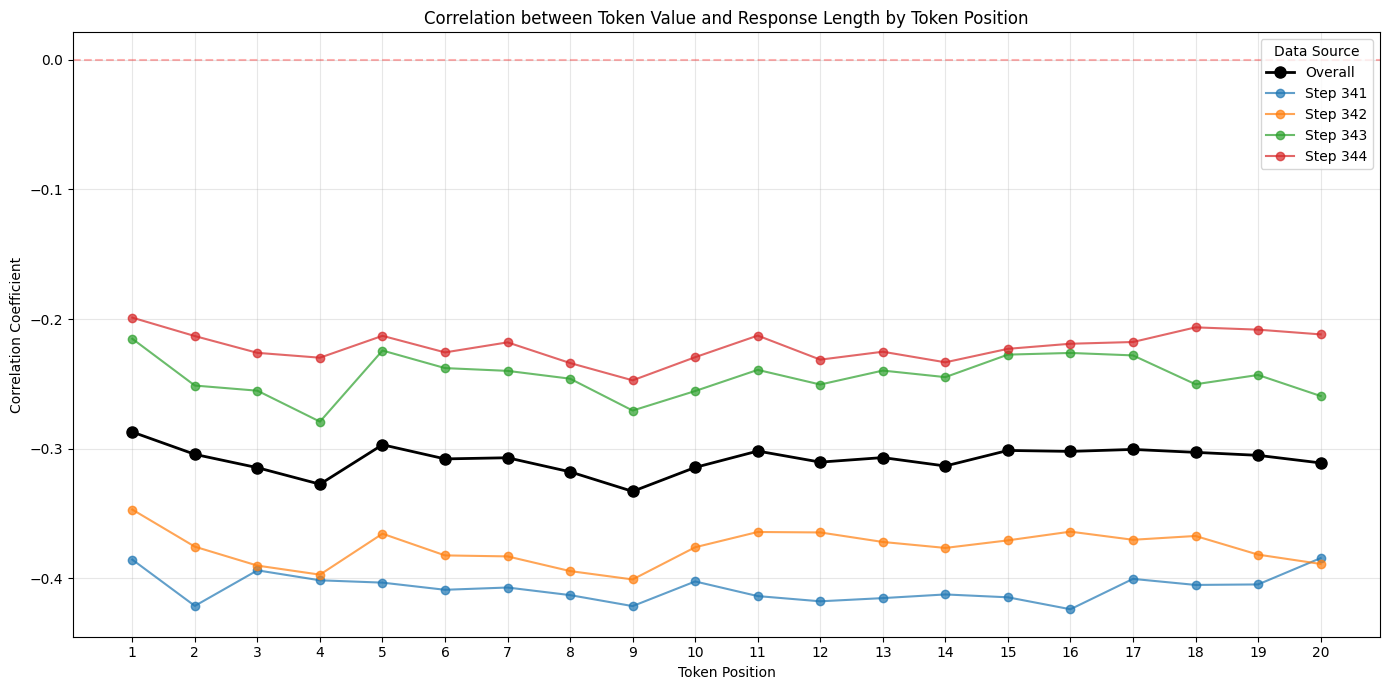

In [55]:
# Plot the correlations by token position
plt.figure(figsize=(14, 7))

# Plot overall correlation
plt.plot(position_corr_df['position'], position_corr_df['overall_corr'], 
         'o-', linewidth=2, label='Overall', color='black', markersize=8)

# Plot step-wise correlations
step_columns = [col for col in position_corr_df.columns if col.startswith('step_')]
for col in step_columns:
    step = col.split('_')[1]
    plt.plot(position_corr_df['position'], position_corr_df[col], 
             'o-', linewidth=1.5, label=f'Step {step}', alpha=0.7)

plt.axhline(y=0, color='r', linestyle='--', alpha=0.3)
plt.title('Correlation between Token Value and Response Length by Token Position')
plt.xlabel('Token Position')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)
plt.legend(title='Data Source')
plt.xticks(position_corr_df['position'])
plt.tight_layout()
plt.show()

# Spearman Correlation Analysis

Let's analyze the relationship using Spearman's rank correlation, which is less sensitive to outliers and can detect monotonic relationships even when they're not strictly linear.

In [ ]:
# Calculate Spearman correlation for first token value and response length
spearman_corr = correlation_df['first_token_value'].corr(correlation_df['response_length'], method='spearman')
print(f"Overall Spearman correlation coefficient: {spearman_corr:.4f}")

# Calculate Spearman correlation by step
spearman_step_correlations = correlation_df.groupby('step').apply(
    lambda x: x['first_token_value'].corr(x['response_length'], method='spearman')
)
print("\nSpearman correlation by step:")
for step, corr in spearman_step_correlations.items():
    print(f"Step {step}: {corr:.4f}")

In [ ]:
# Calculate Spearman correlation for multi-token metrics
spearman_metrics = {
    'first_token': multi_token_df['first_token_value'].corr(multi_token_df['response_length'], method='spearman'),
    'first_3_avg': multi_token_df['first_3_avg'].corr(multi_token_df['response_length'], method='spearman'),
    'first_5_avg': multi_token_df['first_5_avg'].corr(multi_token_df['response_length'], method='spearman'),
    'first_10_avg': multi_token_df['first_10_avg'].corr(multi_token_df['response_length'], method='spearman')
}

print("Overall Spearman correlation coefficients:")
for metric, corr in spearman_metrics.items():
    print(f"{metric}: {corr:.4f}")

# Calculate Spearman correlation by step for each metric
print("\nSpearman correlation by step:")
for step in steps:
    step_data = multi_token_df[multi_token_df['step'] == step]
    print(f"\nStep {step}:")
    for col in ['first_token_value', 'first_3_avg', 'first_5_avg', 'first_10_avg']:
        corr = step_data[col].corr(step_data['response_length'], method='spearman')
        print(f"{col}: {corr:.4f}")

In [ ]:
# Create a comparison of Pearson vs Spearman correlations
metric_names = ['first_token', 'first_3_avg', 'first_5_avg', 'first_10_avg']
correlation_comparison = pd.DataFrame({
    'Metric': metric_names,
    'Pearson': [correlation_metrics[m] for m in metric_names],
    'Spearman': [spearman_metrics[m] for m in metric_names]
})

print("Correlation coefficient comparison (Pearson vs Spearman):")
print(correlation_comparison)

# Plot comparison
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(metric_names))

plt.bar(x - bar_width/2, correlation_comparison['Pearson'], bar_width, label='Pearson')
plt.bar(x + bar_width/2, correlation_comparison['Spearman'], bar_width, label='Spearman')

plt.xlabel('Token Value Metric')
plt.ylabel('Correlation Coefficient')
plt.title('Comparison of Pearson and Spearman Correlation Coefficients')
plt.xticks(x, metric_names)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Analyze Spearman correlation for individual token positions
position_spearman_corr = []

for pos in range(max_tokens_to_analyze):
    token_values = []
    response_lengths = []
    steps = []
    
    for i, values in enumerate(all_values_list):
        if len(values) > pos:  # Check if this position exists
            token_values.append(float(values[pos]))
            response_lengths.append(all_response_lengths[i])
            steps.append(all_step_info[i])
    
    # Create a DataFrame for this position
    pos_df = pd.DataFrame({
        'token_value': token_values,
        'response_length': response_lengths,
        'step': steps
    })
    
    # Calculate overall Spearman correlation
    overall_corr = pos_df['token_value'].corr(pos_df['response_length'], method='spearman')
    
    # Calculate Spearman correlation by step
    step_corrs = {}
    for step in pd.unique(pos_df['step']):
        step_data = pos_df[pos_df['step'] == step]
        step_corrs[step] = step_data['token_value'].corr(step_data['response_length'], method='spearman')
    
    position_spearman_corr.append({
        'position': pos + 1,  # 1-indexed for clarity
        'overall_corr': overall_corr,
        **{f'step_{step}': corr for step, corr in step_corrs.items()}
    })

position_spearman_df = pd.DataFrame(position_spearman_corr)
print("Spearman correlation by token position:")
print(position_spearman_df)

In [ ]:
# Plot comparison between Pearson and Spearman correlations by token position
plt.figure(figsize=(14, 7))

# Plot overall Pearson correlation
plt.plot(position_corr_df['position'], position_corr_df['overall_corr'], 
         'o-', linewidth=2, label='Pearson (Overall)', color='blue', markersize=8)

# Plot overall Spearman correlation
plt.plot(position_spearman_df['position'], position_spearman_df['overall_corr'], 
         'o-', linewidth=2, label='Spearman (Overall)', color='red', markersize=8)

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.3)
plt.title('Comparison of Pearson and Spearman Correlations by Token Position')
plt.xlabel('Token Position')
plt.ylabel('Correlation Coefficient')
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(position_corr_df['position'])
plt.tight_layout()
plt.show()

## Interpretation of Correlation Strength

General guidelines for interpreting correlation coefficients:

| Correlation Coefficient (absolute value) | Interpretation      |
|------------------------------------------|---------------------|
| 0.00 - 0.19                             | Very weak           |
| 0.20 - 0.39                             | Weak                |
| 0.40 - 0.59                             | Moderate            |
| 0.60 - 0.79                             | Strong              |
| 0.80 - 1.00                             | Very strong         |

Coefficient of determination (r²) indicates the proportion of variance in the dependent variable that can be explained by the independent variable.

In [ ]:
# Calculate coefficient of determination (r-squared) for both correlation types
r_squared_comparison = pd.DataFrame({
    'Metric': metric_names,
    'Pearson_r': [correlation_metrics[m] for m in metric_names],
    'Pearson_r²': [correlation_metrics[m]**2 for m in metric_names],
    'Spearman_r': [spearman_metrics[m] for m in metric_names],
    'Spearman_r²': [spearman_metrics[m]**2 for m in metric_names]
})

print("Coefficient of determination (r²) by metric:")
print(r_squared_comparison)

# Plot r-squared values
plt.figure(figsize=(10, 6))
bar_width = 0.35
x = np.arange(len(metric_names))

plt.bar(x - bar_width/2, r_squared_comparison['Pearson_r²'], bar_width, label='Pearson r²')
plt.bar(x + bar_width/2, r_squared_comparison['Spearman_r²'], bar_width, label='Spearman r²')

plt.xlabel('Token Value Metric')
plt.ylabel('r² (Variance Explained)')
plt.title('Proportion of Response Length Variance Explained by Token Value Metrics')
plt.xticks(x, metric_names)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()